# 🎬 OTT Data Analysis using Matplotlib

We will explore and visualize data from an OTT platform dataset, covering:

- TV Shows vs Movies count
- Content Rating distribution (Pie)
- Movie duration distribution (Histogram)
- Shows released per year (Scatter)
- Top 10 content-producing countries (Barh)
- Movies vs Shows per year (Subplots)


# First step
1) Importing libraries 
2) Reading dataset
3) Loading 1st five rows to check if its usable

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\wwwsh\OneDrive\Desktop\proj_1\data_sci\mat_practice\ott.csv', encoding='latin1')
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  ... Unnamed: 16  \
0  September 25, 2021          2020  PG-13     90 min  ...         NaN   
1  September 24, 2021          2021  TV-MA  2 Season

## Removing duplicate values 

In [2]:
df=df.dropna(subset=['type','release_year','rating','country','duration'])

# Graphs and figures


## 1. TV Show vs Movie Count (Bar Chart)

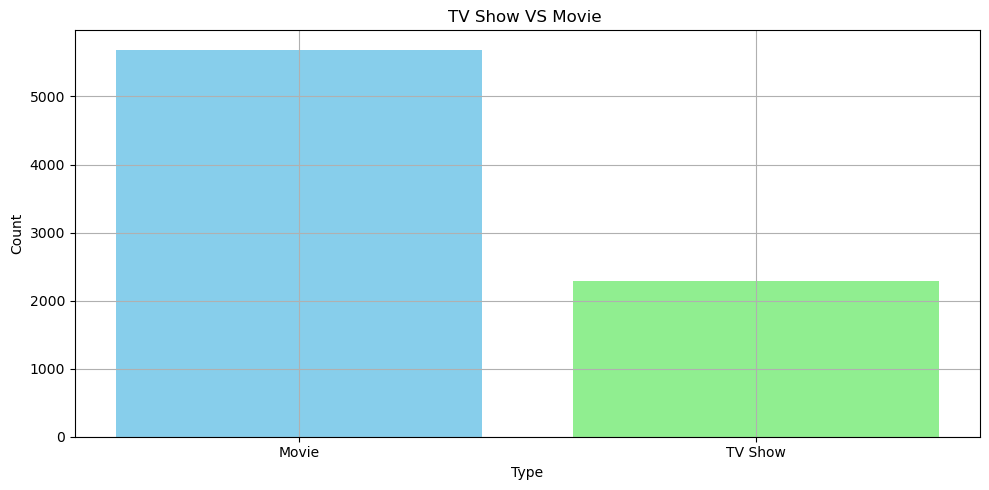

In [3]:
jat = df['type'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(jat.index, jat.values, color=['skyblue', 'lightgreen'])
plt.title('TV Show VS Movie ')
plt.xlabel('Type')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'C:\Users\wwwsh\OneDrive\Desktop\proj_1\data_sci\mat_practice\figures\first.png', dpi=300, bbox_inches='tight')
plt.show()


# 2. Rating Distribution (Pie Chart)


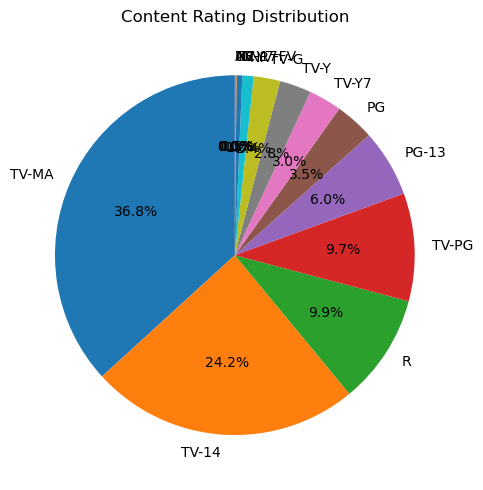

In [4]:
rate_count = df['rating'].value_counts()

plt.figure(figsize=(10, 5))
plt.pie(rate_count, labels=rate_count.index, autopct='%1.1f%%', startangle=90)
# %1.1f%% = keep 1 decimal place + show % sign
plt.title('Content Rating Distribution')
plt.tight_layout()
plt.savefig(r'C:\Users\wwwsh\OneDrive\Desktop\proj_1\data_sci\mat_practice\figures\second.png', dpi=300, bbox_inches='tight')
plt.show()


# 3. Movie Duration Distribution (Histogram)

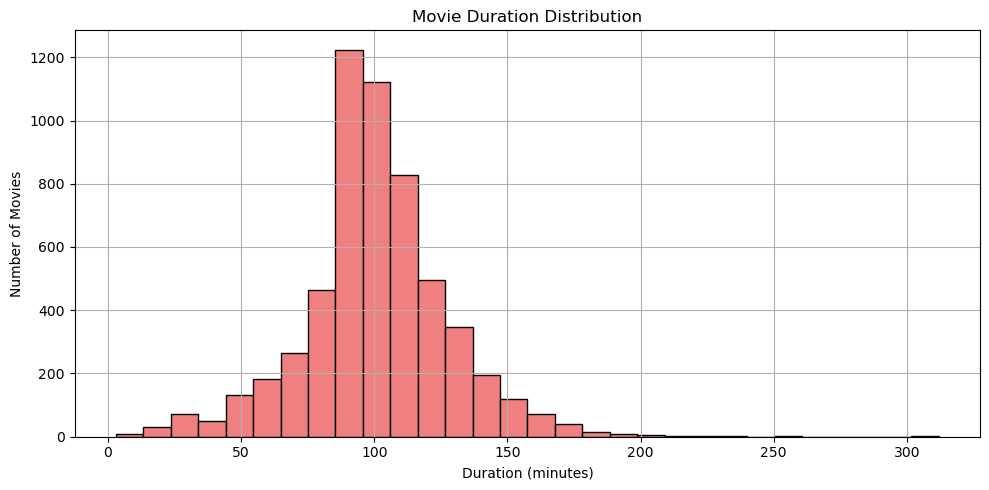

In [5]:
cinema = df[df['type'] == 'Movie'].copy()
cinema['duration_int'] = cinema['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(10, 5))
plt.hist(cinema['duration_int'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'C:\Users\wwwsh\OneDrive\Desktop\proj_1\data_sci\mat_practice\figures\third.png', dpi=300, bbox_inches='tight')
plt.show()


# 4. Shows Released Per Year (Scatter Plot)

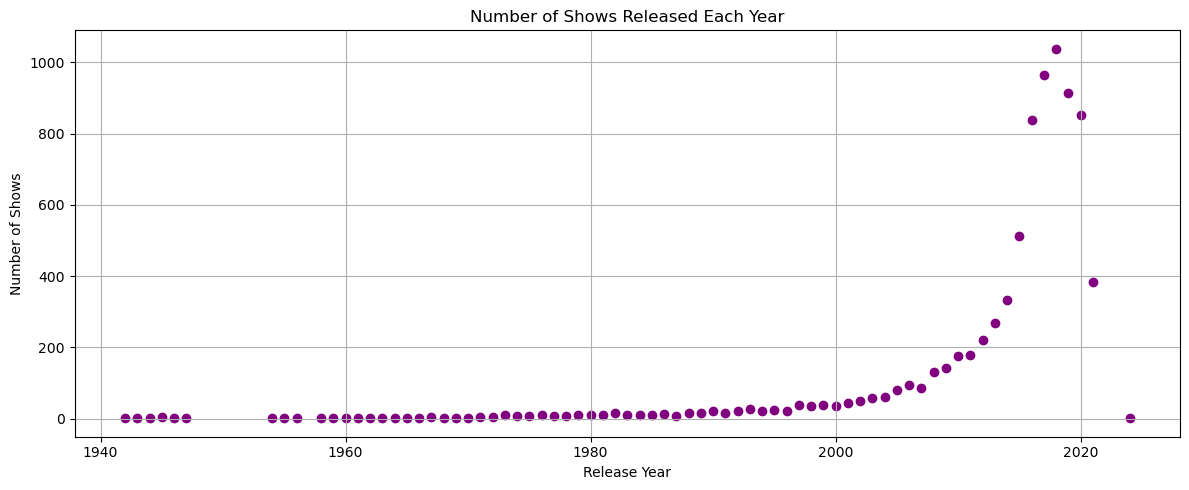

In [7]:
rel_count = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.scatter(rel_count.index, rel_count.values, color='purple')
plt.title('Number of Shows Released Each Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'C:\Users\wwwsh\OneDrive\Desktop\proj_1\data_sci\mat_practice\figures\fourth.png', dpi=300, bbox_inches='tight')
plt.show()


#  5. Top 10 Countries by Content (Horizontal Bar Chart)

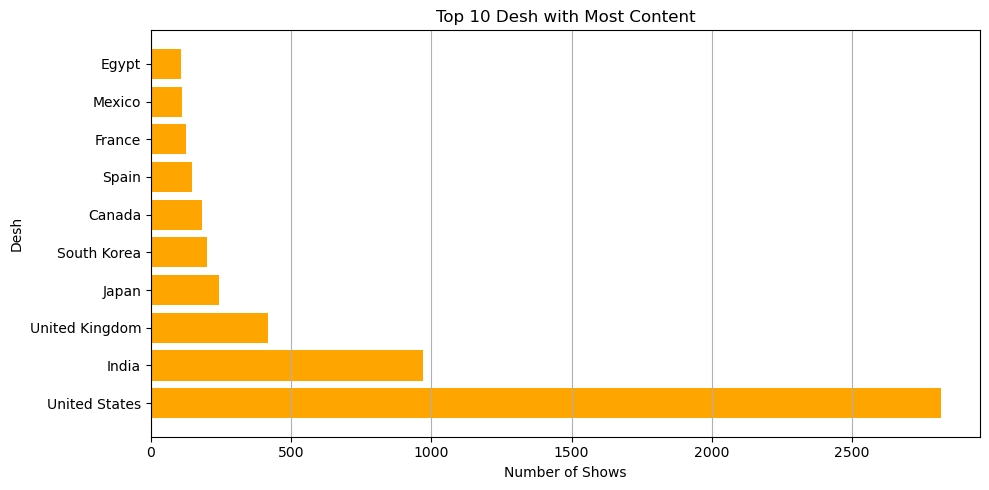

In [8]:
desh_ginti = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(desh_ginti.index, desh_ginti.values, color='orange')
plt.title('Top 10 Desh with Most Content')
plt.xlabel('Number of Shows')
plt.ylabel('Desh')
plt.grid(axis='x')
plt.tight_layout()
plt.savefig(r'C:\Users\wwwsh\OneDrive\Desktop\proj_1\data_sci\mat_practice\figures\fifth.png', dpi=300, bbox_inches='tight')
plt.show()


# 6. Movies vs TV Shows per Year (Subplot)

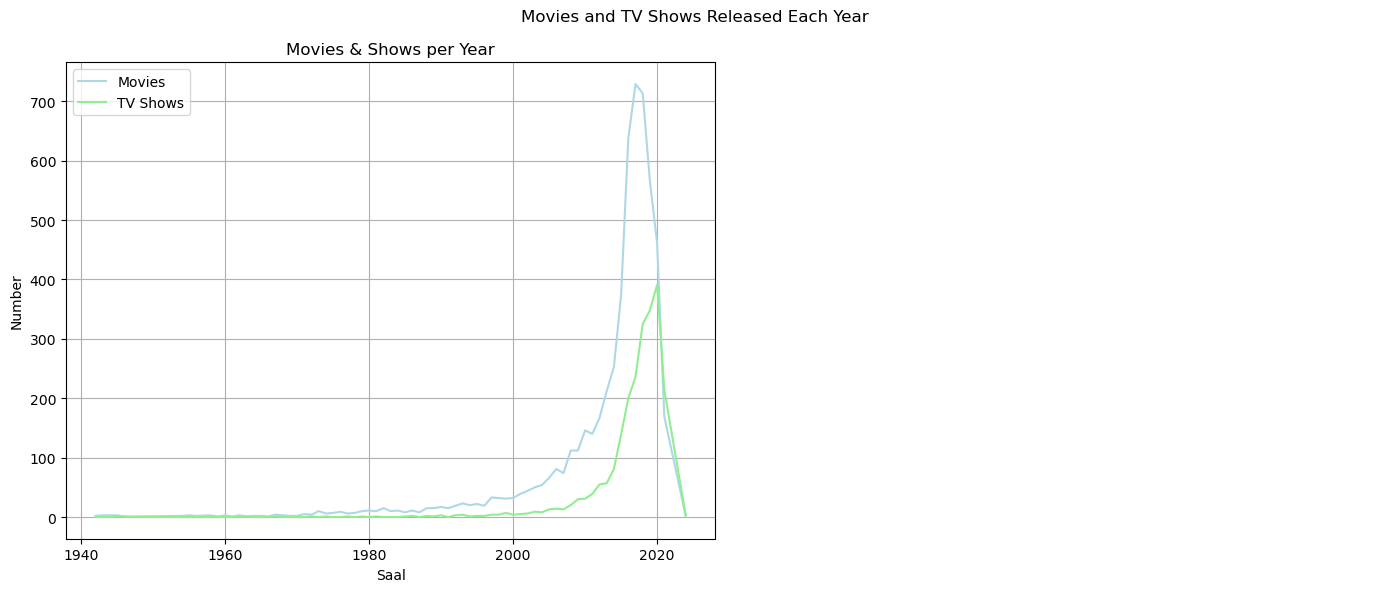

In [9]:
year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot – Movies
ax[0].plot(year.index, year['Movie'], color='lightblue', label='Movies')
ax[0].plot(year.index, year['TV Show'], color='lightgreen', label='TV Shows')
ax[0].set_title('Movies & Shows per Year')
ax[0].set_xlabel('Saal')
ax[0].set_ylabel('Number')
ax[0].legend()
ax[0].grid(True)

# Right Plot – Left Blank or Off
ax[1].axis('off')

fig.suptitle('Movies and TV Shows Released Each Year')
plt.tight_layout()
plt.savefig(r'C:\Users\wwwsh\OneDrive\Desktop\proj_1\data_sci\mat_practice\figures\sixth.png', dpi=300, bbox_inches='tight')
plt.show()


## NOTE - to clone the project , change the CSV path and the Figure saving path 

#  Final Summary

I tried a close-up visual examination of an OTT dataset using **Python**, using `pandas` for data manipulation and `matplotlib` for graphing. I observed a few patterns from the outputs which i have mentioned below :

- **Movie vs TV Show**  
  Movies are more popular, outnumbering TV shows by more than double.

- **Content Ratings**
TV-MA is the most common content rating, then TV-14 and R, to show a strong emphasis on mature audiences.

- **Movie Durations**
Most movies have a runtime concentrated around 90–110 minutes, with a near-normal distribution and very few exceptions .

- **Release Trends**
There's a distinct trend of increased content releases from 2010 and later, peaking just before 2020, and indicating very high growth in digital streaming production.

- **Geographic Distribution**
  The United States supplies the highest amount of content, followed by India and the United Kingdom. The top 10 countries represent the vast majority of entries within the dataset.

- **Year-wise Comparison of Content Type**
  Movies have always had higher numbers than TV shows across all release years, although both have experienced comparable growth.

All visualizations were preserved and structured to facilitate certain insights into type, time, rating, geography, and time-wise trends in content creation. Subplots, pie charts, histograms, and scatter/line plots enabled both the categorical and chronological comprehension of the data.


#   ‎       ㅤㅤㅤㅤ ㅤㅤㅤ                             Thank you for checking my project 😊